# Results Analysis Notebook

This notebook loads experiment results and provides visualizations for comparing DER, JER, and WER across scenarios and microphone configurations.

## What to Track

- **DER (Diarization Error Rate)**: Primary metric for speaker diarization quality
- **JER (Jaccard Error Rate)**: Alternative metric that weights speakers evenly
- **WER (Word Error Rate)**: ASR quality, both integrated and whisper-only
- **Speaker Identification Accuracy**: For scenario 3 only
- **Processing Time**: Per-meeting and total elapsed time

> **Note**: The AMI dataset is stored on the external drive at `/media/ikkjo/StoreJet - Ilija/hf_cache`. This keeps the ~21 GB dataset off the system drive. The experiment configs already include `hf_cache_dir` pointing there.

## Hypotheses to Verify

1. Scenario 3 (reference identification) shows the smallest DER gap between IHM and SDM
2. Scenario 1 (unknown speakers) shows the largest DER gap between IHM and SDM
3. Scenario 2 (oracle speakers) is between the two


In [11]:
import json
import glob
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Set up paths
project_root = Path().resolve().parent
experiments_dir = project_root / "results/experiments"

# Find all experiment output directories
experiment_dirs = [d for d in experiments_dir.iterdir() if d.is_dir()]
print(f"Found {len(experiment_dirs)} experiment directories")
for d in experiment_dirs:
    print(f"  {d.name}")

Found 6 experiment directories
  scenario1_sdm_20260615_214041
  scenario1_ihm_20260615_213920
  scenario2_sdm_20260615_214242
  scenario3_ihm_20260615_214311
  scenario3_sdm_20260615_214338
  scenario2_ihm_20260615_214213


## Load all experiment summaries

In [12]:
all_summaries = []

for exp_dir in experiment_dirs:
    summary_path = exp_dir / "metrics" / "summary.json"
    config_path = exp_dir / "config.json"
    
    if summary_path.exists() and config_path.exists():
        with open(summary_path, "r") as f:
            summary = json.load(f)
        with open(config_path, "r") as f:
            config = json.load(f)
        
        all_summaries.append({
            "experiment_id": config.get("experiment_id", exp_dir.name),
            "scenario": config.get("scenario", "unknown"),
            "mic": config.get("microphone_configuration", "unknown"),
            "summary": summary,
            "output_dir": str(exp_dir),
        })

print(f"Loaded {len(all_summaries)} experiment summaries")
for s in all_summaries:
    print(f"  {s['experiment_id']} (scenario={s['scenario']}, mic={s['mic']})")

Loaded 6 experiment summaries
  scenario1_sdm (scenario=scenario1, mic=sdm)
  scenario1_ihm (scenario=scenario1, mic=ihm)
  scenario2_sdm (scenario=scenario2, mic=sdm)
  scenario3_ihm (scenario=scenario3, mic=ihm)
  scenario3_sdm (scenario=scenario3, mic=sdm)
  scenario2_ihm (scenario=scenario2, mic=ihm)


## Aggregate DER by scenario and microphone

In [13]:
# Build comparison table
import pandas as pd

rows = []
for s in all_summaries:
    der = s['summary'].get('der', {})
    jer = s['summary'].get('jer', {})
    wer = s['summary'].get('wer_integrated', {})
    speaker_acc = s['summary'].get('speaker_identification_accuracy', {})
    
    rows.append({
        "experiment_id": s['experiment_id'],
        "scenario": s['scenario'],
        "mic": s['mic'],
        "num_meetings": s['summary'].get('num_completed', 0),
        "mean_der": der.get('mean'),
        "std_der": der.get('std'),
        "min_der": der.get('min'),
        "max_der": der.get('max'),
        "mean_jer": jer.get('mean'),
        "std_jer": jer.get('std'),
        "mean_wer": wer.get('mean'),
        "std_wer": wer.get('std'),
        "speaker_acc": speaker_acc.get('mean'),
        "elapsed_time": s['summary'].get('elapsed_seconds', {}).get('mean'),
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

# Save to CSV for easy import
csv_path = project_root / "results/metrics/experiment_comparison.csv"
csv_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(csv_path, index=False)
print(f"\nSaved comparison table to: {csv_path}")

experiment_id  scenario mic  num_meetings  mean_der  std_der  min_der  max_der  mean_jer  std_jer  mean_wer  std_wer  speaker_acc  elapsed_time
scenario1_sdm scenario1 sdm            16    0.8063   0.0802   0.6437   0.9694    0.8760   0.0425    0.4237   0.1125          NaN        1.6938
scenario1_ihm scenario1 ihm            16    0.7980   0.0806   0.6284   0.9590    0.8822   0.0234    0.3756   0.0837          NaN        1.5044
scenario2_sdm scenario2 sdm            16    0.5552   0.1327   0.3658   0.8123    0.5589   0.1213    0.4237   0.1125          NaN        1.7163
scenario3_ihm scenario3 ihm            16    0.2956   0.1202   0.1588   0.5498    0.2458   0.0952    0.3756   0.0837       0.8825        1.6131
scenario3_sdm scenario3 sdm            16    0.3438   0.1454   0.1822   0.6976    0.3024   0.1164    0.4237   0.1125       0.8110        1.6631
scenario2_ihm scenario2 ihm            16    0.5142   0.1221   0.3348   0.6848    0.5102   0.1330    0.3756   0.0837          NaN       

## Visualize DER by scenario and microphone

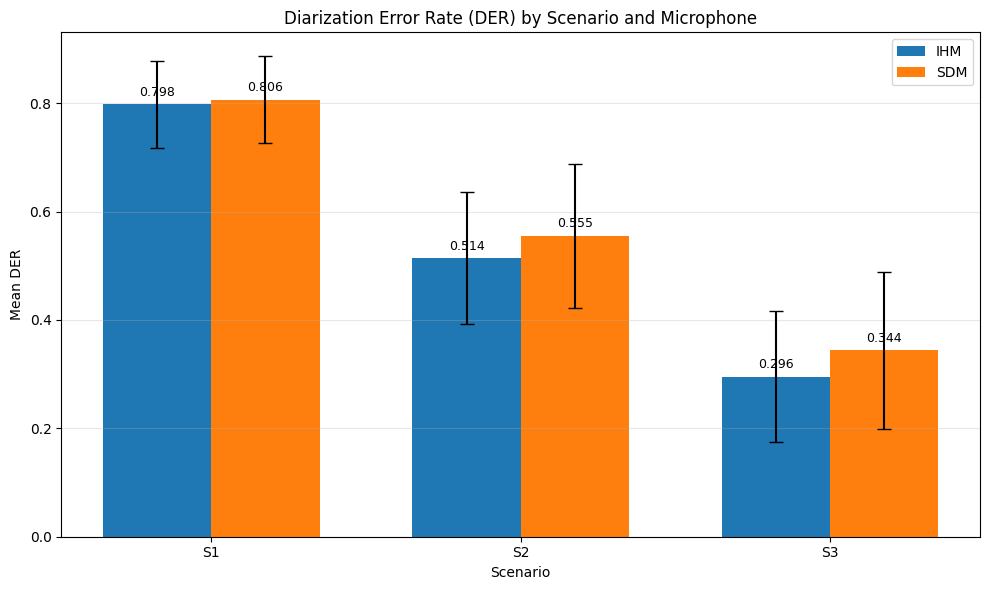

Saved plot to: /home/ikkjo/projects/ppviimu-projekat/automatic-transcription-speaker-id/results/visualizations/der_by_scenario_mic.png


In [14]:
# Bar chart: mean DER by scenario, grouped by mic
fig, ax = plt.subplots(figsize=(10, 6))

scenarios = sorted(df['scenario'].unique())
mics = sorted(df['mic'].unique())

x = np.arange(len(scenarios))
width = 0.35

for i, mic in enumerate(mics):
    mic_data = df[df['mic'] == mic]
    means = [mic_data[mic_data['scenario'] == s]['mean_der'].values[0] if len(mic_data[mic_data['scenario'] == s]) > 0 else 0 for s in scenarios]
    stds = [mic_data[mic_data['scenario'] == s]['std_der'].values[0] if len(mic_data[mic_data['scenario'] == s]) > 0 else 0 for s in scenarios]
    
    bars = ax.bar(x + i * width, means, width, label=mic.upper(), yerr=stds, capsize=5)
    
    # Add value labels on bars
    for bar, mean in zip(bars, means):
        if mean is not None and not np.isnan(mean):
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                   f'{mean:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Scenario')
ax.set_ylabel('Mean DER')
ax.set_title('Diarization Error Rate (DER) by Scenario and Microphone')
ax.set_xticks(x + width / 2)
ax.set_xticklabels([s.replace('scenario', 'S') for s in scenarios])
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(project_root / 'results/visualizations/der_by_scenario_mic.png', dpi=150)
plt.show()
print(f"Saved plot to: {project_root / 'results/visualizations/der_by_scenario_mic.png'}")

## Visualize WER comparison

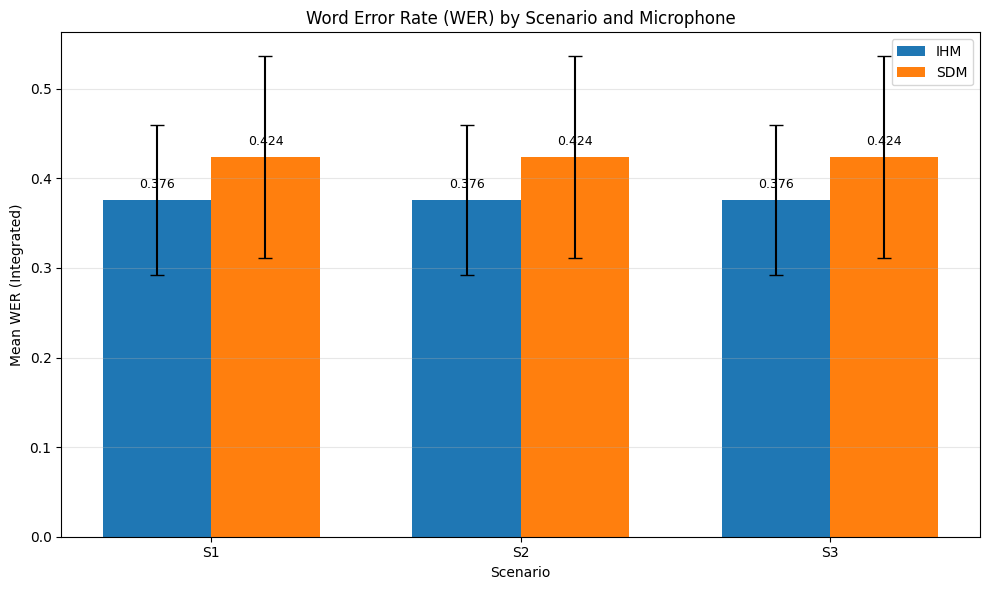

Saved plot to: /home/ikkjo/projects/ppviimu-projekat/automatic-transcription-speaker-id/results/visualizations/wer_by_scenario_mic.png


In [15]:
# Bar chart: mean WER (integrated) by scenario, grouped by mic
fig, ax = plt.subplots(figsize=(10, 6))

for i, mic in enumerate(mics):
    mic_data = df[df['mic'] == mic]
    means = [mic_data[mic_data['scenario'] == s]['mean_wer'].values[0] if len(mic_data[mic_data['scenario'] == s]) > 0 else 0 for s in scenarios]
    stds = [mic_data[mic_data['scenario'] == s]['std_wer'].values[0] if len(mic_data[mic_data['scenario'] == s]) > 0 else 0 for s in scenarios]
    
    bars = ax.bar(x + i * width, means, width, label=mic.upper(), yerr=stds, capsize=5)
    
    for bar, mean in zip(bars, means):
        if mean is not None and not np.isnan(mean):
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                   f'{mean:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Scenario')
ax.set_ylabel('Mean WER (Integrated)')
ax.set_title('Word Error Rate (WER) by Scenario and Microphone')
ax.set_xticks(x + width / 2)
ax.set_xticklabels([s.replace('scenario', 'S') for s in scenarios])
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(project_root / 'results/visualizations/wer_by_scenario_mic.png', dpi=150)
plt.show()
print(f"Saved plot to: {project_root / 'results/visualizations/wer_by_scenario_mic.png'}")

## IHM vs SDM DER gap analysis

DER gap (SDM - IHM) by scenario:
 scenario  ihm_der  sdm_der    gap
scenario1   0.7980   0.8063 0.0083
scenario2   0.5142   0.5552 0.0410
scenario3   0.2956   0.3438 0.0482


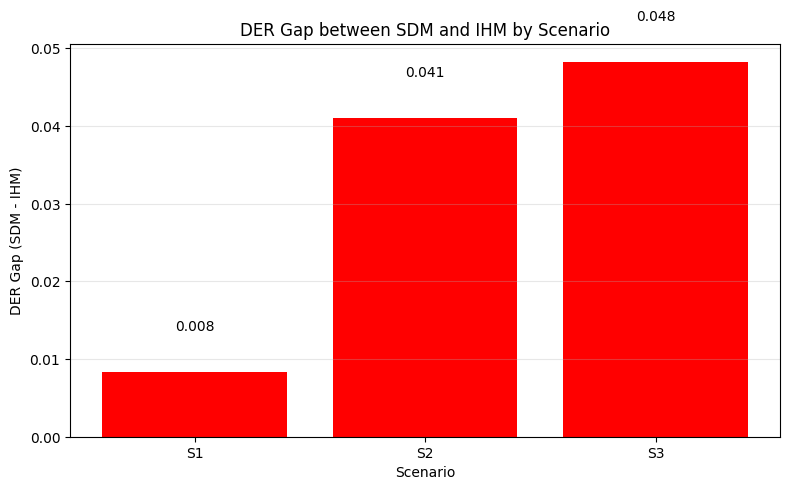

Saved plot to: /home/ikkjo/projects/ppviimu-projekat/automatic-transcription-speaker-id/results/visualizations/der_gap_ihm_vs_sdm.png


In [16]:
# Compute DER gap between IHM and SDM for each scenario
gaps = []
for scenario in scenarios:
    scenario_data = df[df['scenario'] == scenario]
    ihm_der = scenario_data[scenario_data['mic'] == 'ihm']['mean_der'].values
    sdm_der = scenario_data[scenario_data['mic'] == 'sdm']['mean_der'].values
    
    if len(ihm_der) > 0 and len(sdm_der) > 0:
        gap = sdm_der[0] - ihm_der[0]
        gaps.append({
            "scenario": scenario,
            "ihm_der": ihm_der[0],
            "sdm_der": sdm_der[0],
            "gap": gap,
        })

gap_df = pd.DataFrame(gaps)
print("DER gap (SDM - IHM) by scenario:")
print(gap_df.to_string(index=False))

# Bar chart of gaps
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['red' if g['gap'] > 0 else 'green' for g in gaps]
bars = ax.bar([g['scenario'].replace('scenario', 'S') for g in gaps], [g['gap'] for g in gaps], color=colors)

for bar, gap in zip(bars, [g['gap'] for g in gaps]):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
           f'{gap:.3f}', ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Scenario')
ax.set_ylabel('DER Gap (SDM - IHM)')
ax.set_title('DER Gap between SDM and IHM by Scenario')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(project_root / 'results/visualizations/der_gap_ihm_vs_sdm.png', dpi=150)
plt.show()
print(f"Saved plot to: {project_root / 'results/visualizations/der_gap_ihm_vs_sdm.png'}")

## Per-meeting DER distribution (box plot)

Loaded 96 per-meeting metric records


/tmp/ipykernel_28724/2109329173.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(scenario_data, labels=[s.replace('scenario', 'S') for s in scenarios], patch_artist=True)


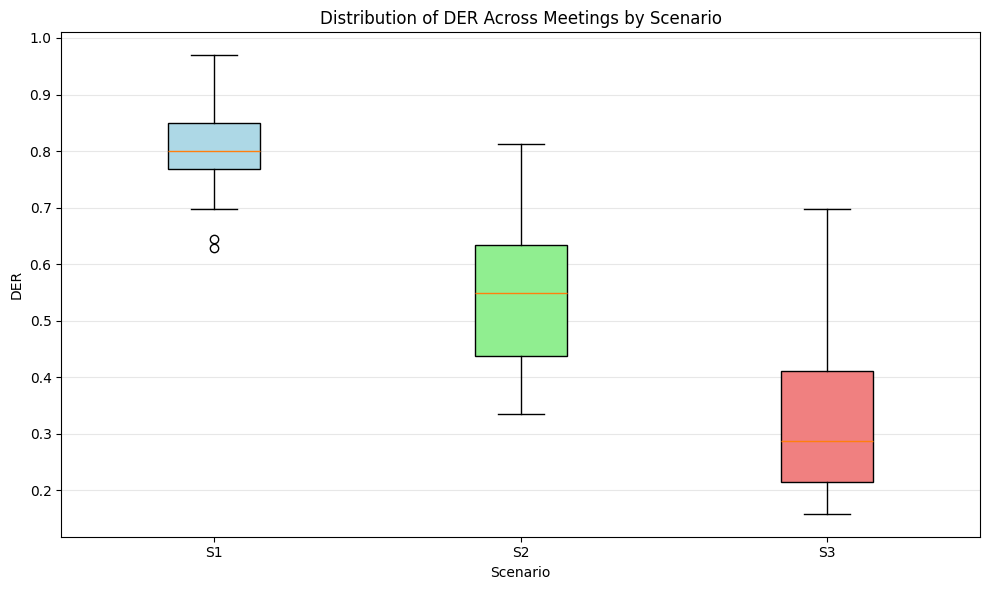

Saved plot to: /home/ikkjo/projects/ppviimu-projekat/automatic-transcription-speaker-id/results/visualizations/der_distribution.png


In [17]:
# Load all per-meeting metrics and build box plot data
all_metrics = []

for exp_dir in experiment_dirs:
    metrics_dir = exp_dir / "metrics"
    config_path = exp_dir / "config.json"
    
    if not config_path.exists():
        continue
    
    with open(config_path, "r") as f:
        config = json.load(f)
    
    for metrics_file in metrics_dir.glob("*.json"):
        if metrics_file.name == "summary.json":
            continue
        try:
            with open(metrics_file, "r") as f:
                metrics = json.load(f)
            all_metrics.append({
                "meeting_id": metrics['meeting_id'],
                "scenario": config.get('scenario', 'unknown'),
                "mic": config.get('microphone_configuration', 'unknown'),
                "der": metrics['der']['der'],
                "jer": metrics['jer']['jer'],
                "wer": metrics['wer']['integrated']['wer'],
            })
        except Exception as e:
            print(f"Error loading {metrics_file}: {e}")

metrics_df = pd.DataFrame(all_metrics)
print(f"Loaded {len(metrics_df)} per-meeting metric records")

# Box plot of DER by scenario
fig, ax = plt.subplots(figsize=(10, 6))

scenario_data = [metrics_df[metrics_df['scenario'] == s]['der'].values for s in scenarios]
bp = ax.boxplot(scenario_data, labels=[s.replace('scenario', 'S') for s in scenarios], patch_artist=True)

colors = ['lightblue', 'lightgreen', 'lightcoral']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_xlabel('Scenario')
ax.set_ylabel('DER')
ax.set_title('Distribution of DER Across Meetings by Scenario')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(project_root / 'results/visualizations/der_distribution.png', dpi=150)
plt.show()
print(f"Saved plot to: {project_root / 'results/visualizations/der_distribution.png'}")

## Identify worst recordings for error analysis

In [18]:
# Find worst meetings by DER for each scenario
for scenario in scenarios:
    scenario_metrics = metrics_df[metrics_df['scenario'] == scenario]
    if len(scenario_metrics) == 0:
        continue
    
    worst = scenario_metrics.nlargest(3, 'der')
    print(f"\n{scenario} - Worst meetings by DER:")
    for _, row in worst.iterrows():
        print(f"  {row['meeting_id']} ({row['mic']}): DER={row['der']:.3f}, WER={row['wer']:.3f}")


scenario1 - Worst meetings by DER:
  ES2004d (sdm): DER=0.969, WER=0.379
  ES2004d (ihm): DER=0.959, WER=0.381
  ES2004a (sdm): DER=0.899, WER=0.352

scenario2 - Worst meetings by DER:
  TS3003d (sdm): DER=0.812, WER=0.630
  ES2004d (sdm): DER=0.712, WER=0.379
  ES2004a (sdm): DER=0.695, WER=0.352

scenario3 - Worst meetings by DER:
  TS3003a (sdm): DER=0.698, WER=0.663
  TS3003d (sdm): DER=0.556, WER=0.630
  TS3003a (ihm): DER=0.550, WER=0.603


## Summary statistics table

In [19]:
# Create a comprehensive summary table
summary_rows = []
for scenario in scenarios:
    for mic in mics:
        subset = metrics_df[(metrics_df['scenario'] == scenario) & (metrics_df['mic'] == mic)]
        if len(subset) == 0:
            continue
        
        summary_rows.append({
            "Scenario": scenario.replace('scenario', 'S'),
            "Mic": mic.upper(),
            "N": len(subset),
            "DER_mean": subset['der'].mean(),
            "DER_std": subset['der'].std(),
            "JER_mean": subset['jer'].mean(),
            "WER_mean": subset['wer'].mean(),
            "DER_min": subset['der'].min(),
            "DER_max": subset['der'].max(),
        })

summary_table = pd.DataFrame(summary_rows)
print("\nComprehensive Summary Table:")
print(summary_table.to_string(index=False, float_format='%.3f'))

# Save to CSV
csv_path = project_root / 'results/metrics/summary_table.csv'
summary_table.to_csv(csv_path, index=False, float_format='%.4f')
print(f"\nSaved summary table to: {csv_path}")


Comprehensive Summary Table:
Scenario Mic  N  DER_mean  DER_std  JER_mean  WER_mean  DER_min  DER_max
      S1 IHM 16     0.798    0.081     0.882     0.376    0.628    0.959
      S1 SDM 16     0.806    0.080     0.876     0.424    0.644    0.969
      S2 IHM 16     0.514    0.122     0.510     0.376    0.335    0.685
      S2 SDM 16     0.555    0.133     0.559     0.424    0.366    0.812
      S3 IHM 16     0.296    0.120     0.246     0.376    0.159    0.550
      S3 SDM 16     0.344    0.145     0.302     0.424    0.182    0.698

Saved summary table to: /home/ikkjo/projects/ppviimu-projekat/automatic-transcription-speaker-id/results/metrics/summary_table.csv


## Verify hypotheses

In [20]:
print("Hypothesis Verification:")
print("="*60)

if len(gap_df) >= 3:
    # Find gaps for each scenario
    s1_gap = gap_df[gap_df['scenario'] == 'scenario1']['gap'].values
    s2_gap = gap_df[gap_df['scenario'] == 'scenario2']['gap'].values
    s3_gap = gap_df[gap_df['scenario'] == 'scenario3']['gap'].values
    
    s1_gap = s1_gap[0] if len(s1_gap) > 0 else None
    s2_gap = s2_gap[0] if len(s2_gap) > 0 else None
    s3_gap = s3_gap[0] if len(s3_gap) > 0 else None
    
    print(f"Scenario 1 DER gap: {s1_gap:.3f}")
    print(f"Scenario 2 DER gap: {s2_gap:.3f}")
    print(f"Scenario 3 DER gap: {s3_gap:.3f}")
    
    if s1_gap is not None and s2_gap is not None and s3_gap is not None:
        # H1: Scenario 3 has smallest gap
        h1 = s3_gap <= min(s1_gap, s2_gap)
        print(f"\nH1: Scenario 3 smallest DER gap (SDM vs IHM): {h1} {'✓' if h1 else '✗'}")
        
        # H2: Scenario 1 has largest gap
        h2 = s1_gap >= max(s2_gap, s3_gap)
        print(f"H2: Scenario 1 largest DER gap (SDM vs IHM): {h2} {'✓' if h2 else '✗'}")
        
        # H3: Scenario 2 is between
        h3 = min(s1_gap, s3_gap) <= s2_gap <= max(s1_gap, s3_gap)
        print(f"H3: Scenario 2 between S1 and S3: {h3} {'✓' if h3 else '✗'}")
    else:
        print("\nNot enough data to verify hypotheses (missing scenario results)")
else:
    print("\nNot enough experiments to verify hypotheses")

print("\nNote: These are descriptive comparisons only. With limited meetings,")
print("parametric statistical tests (t-tests/ANOVA) are not appropriate.")

Hypothesis Verification:
Scenario 1 DER gap: 0.008
Scenario 2 DER gap: 0.041
Scenario 3 DER gap: 0.048

H1: Scenario 3 smallest DER gap (SDM vs IHM): False ✗
H2: Scenario 1 largest DER gap (SDM vs IHM): False ✗
H3: Scenario 2 between S1 and S3: True ✓

Note: These are descriptive comparisons only. With limited meetings,
parametric statistical tests (t-tests/ANOVA) are not appropriate.
